# CP260 Robotic Perception — Final Project
## Metric-Semantic 6D Pose Estimation of PC Back-Panel Components
**Malika T M (SR No. 25909) · Yashita Jaiswal (SR No. 26044)**  
RBCCPS, Indian Institute of Science Bangalore

### Pipeline
- **Stage A** — Data preparation (images, poses, intrinsics, annotations)
- **Stage B** — Per-socket 3D reconstruction via corner triangulation + plane fitting
- **Stage C** — 6D pose construction (center, local axes, rotation, 4×4 transform)
- **Stage D** — Multi-view reprojection refinement
- **Stage E** — Run full pipeline for all annotated sockets

## Setup

In [ ]:
!pip install opencv-python-headless numpy scipy tqdm -q
print('Done')

Done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports

In [ ]:
import os, json, glob, zipfile, warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## Stage A — Data Preparation

In [ ]:
# ── A0: Paths & unzip ────────────────────────────────────────────────────
DATA_DIR   = Path("/content/data/Data")
OUTPUT_DIR = Path("/content/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/detections', exist_ok=True)

zip_path = "/content/drive/MyDrive/Data.zip"
if not DATA_DIR.exists():
    extract_to = Path("/content/data")
    extract_to.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    print("Unzipped.")

print("DATA_DIR →", DATA_DIR)
print("OUTPUT_DIR →", OUTPUT_DIR)

Unzipped.
DATA_DIR → /content/data/Data
OUTPUT_DIR → /content/outputs


In [ ]:
# ── A1: Intrinsics ───────────────────────────────────────────────────────
FX, FY = 1477.00974684544, 1480.4424455584467
CX, CY = 1298.2501500778505, 686.8201623541711
W,  H  = 2560, 1440

K = np.array([[FX,  0., CX],
              [ 0., FY, CY],
              [ 0.,  0.,  1.]], dtype=np.float64)

print('Camera intrinsics K:')
print(K)
print(f'Image size: {W}\u00d7{H}')
print(f'Horizontal FoV: {2*np.degrees(np.arctan(W/(2*FX))):.1f} deg')

Camera intrinsics K:
[[1.47700975e+03 0.00000000e+00 1.29825015e+03]
 [0.00000000e+00 1.48044245e+03 6.86820162e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Image size: 2560×1440
Horizontal FoV: 81.8 deg


In [ ]:
# ── A2: Poses ────────────────────────────────────────────────────────────
# poses.json: frame_index (str) → 4×4 camera-to-world matrix
with open(DATA_DIR / "poses.json") as f:
    all_poses_raw = json.load(f)
all_poses = {int(k): np.array(v, dtype=np.float64)
             for k, v in all_poses_raw.items()}
print(f'Loaded {len(all_poses)} camera poses')

Loaded 704 camera poses


In [ ]:
# ── A3: Images ───────────────────────────────────────────────────────────
images_bgr = {}
for fp in sorted(glob.glob(str(DATA_DIR / "frame_*.png"))):
    idx = int(os.path.basename(fp).replace('frame_', '').replace('.png', ''))
    images_bgr[idx] = cv2.imread(fp)
print(f'Loaded {len(images_bgr)} images: {sorted(images_bgr.keys())}')

Loaded 16 images: [319, 333, 353, 359, 365, 371, 390, 400, 426, 449, 461, 468, 471, 496, 515, 531]


In [ ]:
# ── A4: Load & convert manual annotations from pixspy ────────────────────
# Input  (pixspy): {filename: {socket_key: {tl,tr,br,bl} | null}}
# Output (pipeline): {socket_type: {frame_idx(int): [[u,v]×4]}}

CORNER_ORDER = ['tl', 'tr', 'br', 'bl']

def convert_annotations(raw_path: Path) -> dict:
    with open(raw_path) as f:
        raw = json.load(f)
    converted = {}
    for filename, sockets in raw.items():
        frame_id = int(Path(filename).stem.replace('frame_', ''))
        for socket_key, corners in sockets.items():
            if corners is None:
                continue
            socket_type = socket_key.replace('_socket', '')
            converted.setdefault(socket_type, {})[frame_id] = [
                corners[c] for c in CORNER_ORDER
            ]
    for st, frames in converted.items():
        print(f'  {st}: {len(frames)} frames')
    return converted

print('Annotations:')
CORNER_ANNOTATIONS = convert_annotations(Path("/annotations.json"))

Annotations:
  power: 13 frames
  ethernet: 13 frames


In [ ]:
# ── A4b: Build bbox format for Stage B ───────────────────────────────────
# Stage B expects {entity_name: {frame_idx: [x1,y1,x2,y2]}}

def corners_to_bbox(corners_uv):
    """[[u,v]×4] → [x1, y1, x2, y2]"""
    us = [c[0] for c in corners_uv]
    vs = [c[1] for c in corners_uv]
    return [min(us), min(vs), max(us), max(vs)]

ENTITY_ANNOTATIONS = {}
for socket_type, frames in CORNER_ANNOTATIONS.items():
    entity_name = socket_type + '_socket'
    ENTITY_ANNOTATIONS[entity_name] = {
        fid: corners_to_bbox(corners)
        for fid, corners in frames.items()
    }

print('ENTITY_ANNOTATIONS summary:')
for ename, frames in ENTITY_ANNOTATIONS.items():
    print(f'  {ename}: frames {sorted(frames.keys())}')

ENTITY_ANNOTATIONS summary:
  power_socket: frames [319, 333, 353, 359, 365, 400, 426, 449, 461, 468, 471, 496, 531]
  ethernet_socket: frames [333, 353, 359, 365, 371, 390, 426, 449, 461, 468, 471, 496, 515]


In [ ]:
# ── A5: Validate frame naming consistency ────────────────────────────────
print('Annotation validation:')
all_ok = True
for entity, ann in ENTITY_ANNOTATIONS.items():
    for idx in sorted(ann.keys()):
        has_img  = idx in images_bgr
        has_pose = idx in all_poses
        status   = 'OK' if (has_img and has_pose) else 'MISSING \u26a0'
        if not (has_img and has_pose):
            all_ok = False
        print(f'  {entity} frame {idx}: image={has_img}, pose={has_pose} {status}')
print('All OK \u2713' if all_ok else 'Some frames missing \u26a0 \u2014 check above')

Annotation validation:
  power_socket frame 319: image=True, pose=True OK
  power_socket frame 333: image=True, pose=True OK
  power_socket frame 353: image=True, pose=True OK
  power_socket frame 359: image=True, pose=True OK
  power_socket frame 365: image=True, pose=True OK
  power_socket frame 400: image=True, pose=True OK
  power_socket frame 426: image=True, pose=True OK
  power_socket frame 449: image=True, pose=True OK
  power_socket frame 461: image=True, pose=True OK
  power_socket frame 468: image=True, pose=True OK
  power_socket frame 471: image=True, pose=True OK
  power_socket frame 496: image=True, pose=True OK
  power_socket frame 531: image=True, pose=True OK
  ethernet_socket frame 333: image=True, pose=True OK
  ethernet_socket frame 353: image=True, pose=True OK
  ethernet_socket frame 359: image=True, pose=True OK
  ethernet_socket frame 365: image=True, pose=True OK
  ethernet_socket frame 371: image=True, pose=True OK
  ethernet_socket frame 390: image=True, pos

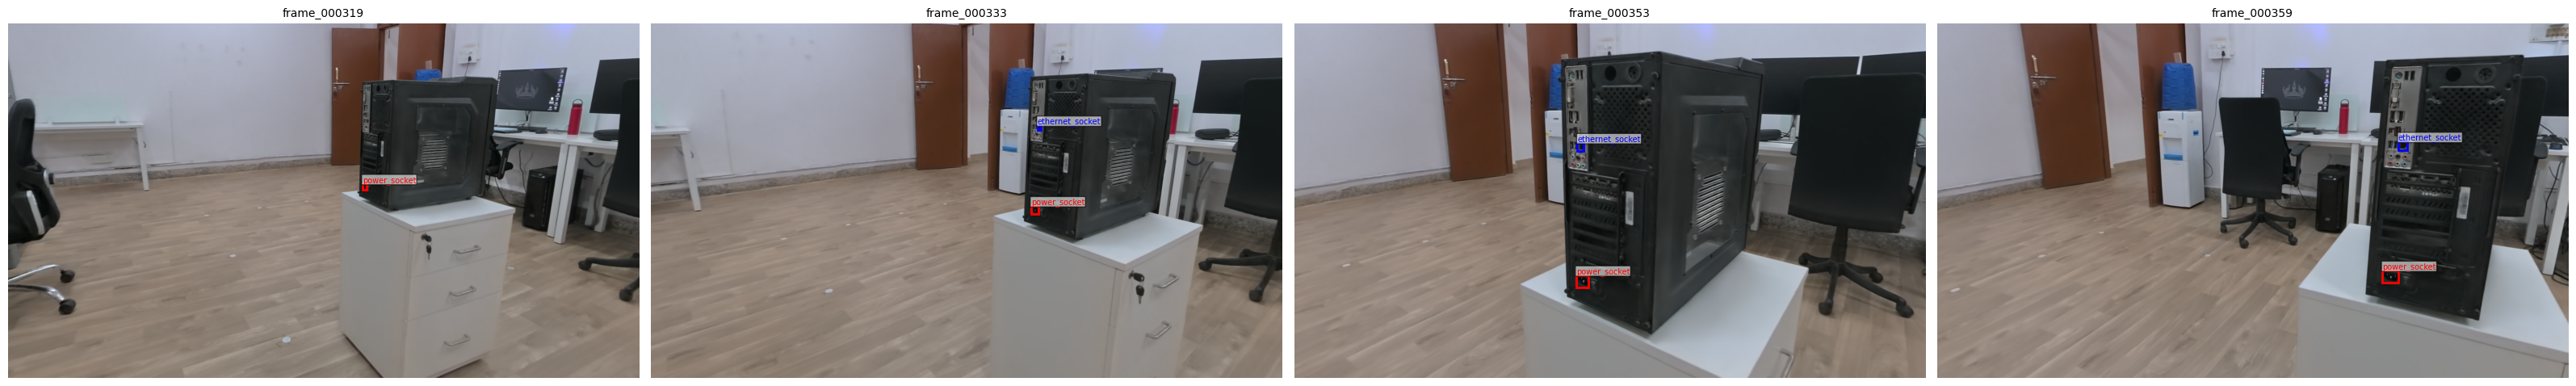

Stage A complete.


In [ ]:
# ── A6: Visualise annotations ────────────────────────────────────────────
COLORS = {
    'power_socket':         (255,   0,   0),
    'ethernet_socket':      (  0,   0, 255),
    'vga_socket':           (  0, 255,   0),
    'hdmi_socket_left':     (255, 165,   0),
    'usb_socket_top_right': (255,   0, 255),
}

viz_frames = [f for f in sorted(images_bgr.keys()) if f in all_poses][:4]
fig, axes = plt.subplots(1, len(viz_frames), figsize=(8*len(viz_frames), 6))
if len(viz_frames) == 1:
    axes = [axes]

for col, idx in enumerate(viz_frames):
    img = cv2.cvtColor(images_bgr[idx], cv2.COLOR_BGR2RGB)
    axes[col].imshow(img)
    for entity, ann in ENTITY_ANNOTATIONS.items():
        if idx in ann:
            x1, y1, x2, y2 = ann[idx]
            c = np.array(COLORS.get(entity, (200, 200, 200))) / 255
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=c, facecolor='none'
            )
            axes[col].add_patch(rect)
            axes[col].text(x1, y1-8, entity, color=c, fontsize=7,
                           bbox=dict(boxstyle='round,pad=0.1',
                                     facecolor='white', alpha=0.6))
    axes[col].set_title(f'frame_{idx:06d}', fontsize=10)
    axes[col].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/annotations.png', dpi=100)
plt.show()
print('Stage A complete.')

## Stage B — Per-Socket 3D Reconstruction

For each entity:
1. Triangulate the 4 bbox corners across all view pairs  
2. Reject outlier points via MAD
3. Fit a plane to the triangulated cloud (SVD)
4. Project all points onto the plane

In [ ]:
# ── B1: Geometry helpers ─────────────────────────────────────────────────

def get_projection_matrix(K, c2w):
    """P = K @ [R|t]  where  [R|t] = inv(c2w)[:3,:]"""
    w2c = np.linalg.inv(c2w)
    return K @ w2c[:3, :]

def triangulate_point_pair(P1, P2, u1, v1, u2, v2):
    """Triangulate one point pair with DLT via cv2.triangulatePoints."""
    pts4d = cv2.triangulatePoints(
        P1, P2,
        np.array([[u1, v1]], dtype=np.float64).T,
        np.array([[u2, v2]], dtype=np.float64).T,
    )
    return (pts4d[:3] / pts4d[3:]).flatten()

def remove_outliers_mad(points, threshold=3.0):
    """MAD-based outlier rejection on a 3D point cloud."""
    if len(points) < 5:
        return points
    median = np.median(points, axis=0)
    diffs  = np.linalg.norm(points - median, axis=1)
    mad    = 1.4826 * np.median(diffs)
    if mad < 1e-10:
        return points
    return points[diffs < threshold * mad]

def fit_plane_svd(points):
    """Fit a plane to (N,3) points via SVD. Returns (unit_normal, centroid)."""
    centroid = np.mean(points, axis=0)
    _, _, Vt = np.linalg.svd(points - centroid)
    normal = Vt[-1]
    return normal, centroid

def project_points_to_plane(points, normal, plane_point):
    """Orthogonally project points onto the plane (normal, plane_point)."""
    d = np.dot(points - plane_point, normal)
    return points - np.outer(d, normal)

print('Stage B helpers loaded.')

Stage B helpers loaded.


In [ ]:
# ── B2: stage_B — corners-only triangulation ────────────────────────────

def stage_B(entity_name, annotations, K, poses):
    """
    Triangulate 4 bbox corners across every view pair.
    4 corners × C(N,2) pairs → ~300 pts for 13 frames.
    Returns: (pts_on_plane, plane_normal, plane_center) or (None,None,None)
    """
    entity_ann    = annotations.get(entity_name, {})
    frame_indices = [f for f in sorted(entity_ann.keys()) if f in poses]

    if len(frame_indices) < 2:
        print(f'  [{entity_name}] ERROR: need \u22652 frames, have {len(frame_indices)}')
        return None, None, None

    all_points = []

    for idx1, idx2 in combinations(frame_indices, 2):
        bbox1 = entity_ann[idx1];  bbox2 = entity_ann[idx2]
        P1    = get_projection_matrix(K, poses[idx1])
        P2    = get_projection_matrix(K, poses[idx2])
        w2c1  = np.linalg.inv(poses[idx1])
        w2c2  = np.linalg.inv(poses[idx2])

        # TL, TR, BL, BR
        corner_pairs = [
            (bbox1[0], bbox1[1], bbox2[0], bbox2[1]),
            (bbox1[2], bbox1[1], bbox2[2], bbox2[1]),
            (bbox1[0], bbox1[3], bbox2[0], bbox2[3]),
            (bbox1[2], bbox1[3], bbox2[2], bbox2[3]),
        ]

        for u1, v1, u2, v2 in corner_pairs:
            pt3d = triangulate_point_pair(P1, P2, u1, v1, u2, v2)
            # Cheirality check
            z1 = (w2c1[:3, :3] @ pt3d + w2c1[:3, 3])[2]
            z2 = (w2c2[:3, :3] @ pt3d + w2c2[:3, 3])[2]
            if z1 <= 0 or z2 <= 0:
                continue
            # Reprojection sanity filter (< 50 px)
            proj1 = P1 @ np.append(pt3d, 1);  proj1 = proj1[:2] / proj1[2]
            proj2 = P2 @ np.append(pt3d, 1);  proj2 = proj2[:2] / proj2[2]
            if (np.linalg.norm(proj1 - [u1, v1]) < 50 and
                    np.linalg.norm(proj2 - [u2, v2]) < 50):
                all_points.append(pt3d)

    if len(all_points) < 3:
        print(f'  [{entity_name}] ERROR: only {len(all_points)} valid points')
        return None, None, None

    pts = remove_outliers_mad(np.array(all_points))

    normal, plane_center = fit_plane_svd(pts)
    if normal[1] < 0:
        normal = -normal          # ensure normal points toward cameras (+Y)

    pts_on_plane = project_points_to_plane(pts, normal, plane_center)
    print(f'  [{entity_name}] {len(pts)} pts  |  '
          f'normal={normal.round(3)}  |  center={plane_center.round(3)}')
    return pts_on_plane, normal, plane_center

print('Stage B ready.')

Stage B ready.


## Stage C — 6D Pose Construction

From the plane-projected point cloud:
1. **Centre** = mean of projected points
2. **Local axes**: row0 = plane normal (+Y), row2 = world X, row1 = row2 × row0
3. **3×3 rotation matrix** R = [row0; row1; row2]
4. **4×4 SE(3) transform** T
5. **Extents** from PCA spread, capped by physical priors

In [24]:
DEPTH_PRIORS = {
    'power_socket':         0.006,
    'ethernet_socket':      0.006,
    'hdmi_socket_left':     0.006,
    'usb_socket_top_right': 0.006,
    'vga_socket':           0.006,
}

PHYSICAL_MAX_EXTENTS = {
    'power_socket':         [0.035, 0.025, 0.006],
    'ethernet_socket':      [0.020, 0.018, 0.006],
    'hdmi_socket_left':     [0.020, 0.012, 0.006],
    'usb_socket_top_right': [0.016, 0.014, 0.006],
    'vga_socket':           [0.040, 0.020, 0.006],
}

def stage_C(entity_name, pts_on_plane, plane_normal):
    """
    Build the full 6D pose (OBB) from the plane-projected point cloud.
    Returns dict: center, extent, rotation, T4x4.
    """
    if pts_on_plane is None or len(pts_on_plane) < 3:
        return None

    # C1: centre
    center = np.mean(pts_on_plane, axis=0)

    # C2: local axes
    row2 = np.array([1., 0., 0.])
    row0 = plane_normal.copy()
    row0[0] = 0.0
    row0 /= (np.linalg.norm(row0) + 1e-12)
    if row0[1] < 0: row0 = -row0
    row1 = np.cross(row2, row0)
    row1 /= (np.linalg.norm(row1) + 1e-12)
    row0 = np.cross(row1, row2)              # re-orthogonalise
    row0 /= (np.linalg.norm(row0) + 1e-12)

    # C3 & C4: R and T
    R = np.array([row0, row1, row2])
    T = np.eye(4);  T[:3, :3] = R;  T[:3, 3] = center

    # C5: extents from PCA spread
    centered   = pts_on_plane - center
    _, eigvecs = np.linalg.eigh(np.cov(centered.T))
    proj_pca   = centered @ eigvecs
    spreads    = (proj_pca.max(axis=0) - proj_pca.min(axis=0)) / 2.0
    depth_prior = DEPTH_PRIORS.get(entity_name, 0.006)
    extent = np.array([spreads[2], max(spreads[1], depth_prior), depth_prior])

    if entity_name in PHYSICAL_MAX_EXTENTS:
        mx = PHYSICAL_MAX_EXTENTS[entity_name]
        extent = np.array([min(extent[i], mx[i]) for i in range(3)])

    # Shift centre to OBB geometric centre
    proj          = centered @ R.T
    center_offset = R.T @ ((proj.min(axis=0) + proj.max(axis=0)) / 2.0)
    center        = center + center_offset
    T[:3, 3]      = center

    print(f'  [{entity_name}] center={center.round(4)},  extent={extent.round(4)}')
    return {'center': center.tolist(), 'extent': extent.tolist(),
            'rotation': R.tolist(), 'T4x4': T.tolist()}

print('Stage C ready.')

Stage C ready.


## Stage D — Multi-View Reprojection Refinement

Project the recovered socket centre back into all annotated frames and minimise
the sum of squared reprojection errors using Nelder-Mead optimisation.

In [25]:
def reprojection_error(center_3d, K, poses, annotations_2d):
    """Mean squared reprojection error (px\u00b2) across all annotated frames."""
    total, n = 0.0, 0
    for idx, bbox in annotations_2d.items():
        if idx not in poses:
            continue
        u_target = (bbox[0] + bbox[2]) / 2.0
        v_target = (bbox[1] + bbox[3]) / 2.0
        w2c    = np.linalg.inv(poses[idx])
        pt_cam = w2c[:3, :3] @ center_3d + w2c[:3, 3]
        if pt_cam[2] <= 0:
            total += 1e6;  continue
        pt_2d  = K @ pt_cam
        u_proj = pt_2d[0] / pt_2d[2]
        v_proj = pt_2d[1] / pt_2d[2]
        total += (u_proj - u_target)**2 + (v_proj - v_target)**2
        n += 1
    return total / max(n, 1)


def stage_D(entity_name, obb, annotations, K, poses, verbose=True):
    """Refine 3D centre by minimising reprojection error (Nelder-Mead)."""
    if obb is None:
        return obb
    entity_ann = {k: v for k, v in annotations.get(entity_name, {}).items()
                  if k in poses}
    if len(entity_ann) < 2:
        if verbose: print(f'  [{entity_name}] Skip refinement (< 2 views)')
        return obb

    center_init = np.array(obb['center'])
    err_before  = reprojection_error(center_init, K, poses, entity_ann)

    result = minimize(
        reprojection_error, center_init,
        args=(K, poses, entity_ann),
        method='Nelder-Mead',
        options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 5000},
    )

    center_refined = result.x
    err_after      = reprojection_error(center_refined, K, poses, entity_ann)

    if verbose:
        print(f'  [{entity_name}] Reprojection error: {err_before:.2f} \u2192 {err_after:.2f} px\u00b2')
        print(f'  [{entity_name}] Centre shift: {np.linalg.norm(center_refined-center_init)*1000:.2f} mm')

    obb_r = dict(obb);  obb_r['center'] = center_refined.tolist()
    R = np.array(obb['rotation'])
    T = np.eye(4);  T[:3,:3] = R;  T[:3,3] = center_refined
    obb_r['T4x4'] = T.tolist()
    return obb_r

print('Stage D ready.')

Stage D ready.


## Visualisation Helpers

In [ ]:
OBB_COLORS = {
    'power_socket':         (  0,   0, 255),
    'ethernet_socket':      (255,   0,   0),
    'vga_socket':           (  0, 255,   0),
    'hdmi_socket_left':     (  0, 165, 255),
    'usb_socket_top_right': (255,   0, 255),
}

def project_obb(obb, K, c2w):
    """Project the 8 corners of an OBB into a camera view."""
    center = np.array(obb['center'])
    extent = np.array(obb['extent'])
    R_obb  = np.array(obb['rotation'])
    signs  = np.array([[-1,-1,-1],[-1,-1,1],[-1,1,-1],[-1,1,1],
                       [ 1,-1,-1],[ 1,-1,1],[ 1,1,-1],[ 1,1,1]], dtype=np.float64)
    corners     = (R_obb @ (signs * extent).T).T + center
    w2c         = np.linalg.inv(c2w)
    corners_cam = (w2c[:3,:3] @ corners.T).T + w2c[:3, 3]
    corners_2d  = np.zeros((8, 2))
    for i in range(8):
        if corners_cam[i, 2] > 0:
            pt = K @ corners_cam[i];  corners_2d[i] = pt[:2] / pt[2]
        else:
            corners_2d[i] = [np.nan, np.nan]
    return corners_2d

def draw_obb(image, corners_2d, label='', color=(0, 255, 0)):
    """Draw an OBB wireframe onto an image."""
    vis   = image.copy();  pts = corners_2d.astype(int)
    edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
    for i, j in edges:
        if not (np.isnan(corners_2d[i]).any() or np.isnan(corners_2d[j]).any()):
            cv2.line(vis, tuple(pts[i]), tuple(pts[j]), color, 2)
    if label:
        valid = pts[~np.isnan(corners_2d).any(axis=1)]
        if len(valid) > 0:
            cv2.putText(vis, label, tuple(valid.min(axis=0) - [0, 10]),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return vis

print('Visualisation helpers ready.')

Visualisation helpers ready.


## Stage E — Run Full Pipeline for All Annotated Sockets

Runs Stages B → C → D for every entity in `ENTITY_ANNOTATIONS`,
saves `answers.json`, and visualises the OBB projections.

In [ ]:
print('=' * 60)
print('Stages B \u2192 C \u2192 D  for all entities')
print('=' * 60)

results = []

for entity_name in ENTITY_ANNOTATIONS.keys():
    print(f'\n>>> {entity_name}')

    pts, normal, _ = stage_B(entity_name, ENTITY_ANNOTATIONS, K, all_poses)
    if pts is None:
        print(f'  SKIP: Stage B failed');  continue

    obb = stage_C(entity_name, pts, normal)
    if obb is None:
        print(f'  SKIP: Stage C failed');  continue

    obb = stage_D(entity_name, obb, ENTITY_ANNOTATIONS, K, all_poses)
    results.append({'entity': entity_name, 'obb': obb})

print(f'\nDone. {len(results)} entities processed.')

Stages B → C → D  for all entities

>>> power_socket
  [power_socket] 311 pts  |  normal=[-0.05   0.998 -0.048]  |  center=[0.29  0.224 0.526]
  [power_socket] center=[0.2895 0.2241 0.5256],  extent=[0.0197 0.0216 0.006 ]
  [power_socket] Reprojection error: 7.43 → 1.74 px²
  [power_socket] Centre shift: 1.05 mm

>>> ethernet_socket
  [ethernet_socket] 312 pts  |  normal=[ 0.022  0.996 -0.083]  |  center=[0.289 0.229 0.756]
  [ethernet_socket] center=[0.2926 0.2293 0.7552],  extent=[0.01   0.0123 0.006 ]
  [ethernet_socket] Reprojection error: 162.36 → 0.97 px²
  [ethernet_socket] Centre shift: 4.00 mm

Done. 2 entities processed.


In [ ]:
# ── Save answers.json ────────────────────────────────────────────────────
answers_path = f'{OUTPUT_DIR}/answers.json'
submission   = [
    {'entity': r['entity'],
     'obb': {'center':   r['obb']['center'],
             'extent':   r['obb']['extent'],
             'rotation': r['obb']['rotation']}}
    for r in results
]

with open(answers_path, 'w') as f:
    json.dump(submission, f, indent=2)

print(f'Saved {len(results)} entities \u2192 {answers_path}')
print(json.dumps(submission, indent=2))

Saved 2 entities → /content/outputs/answers.json
[
  {
    "entity": "power_socket",
    "obb": {
      "center": [
        0.28997311068809556,
        0.22501215955332285,
        0.5257812001757787
      ],
      "extent": [
        0.019708448442155496,
        0.021627409558727086,
        0.006
      ],
      "rotation": [
        [
          0.0,
          0.9988416978285708,
          -0.048117176527080044
        ],
        [
          -0.0,
          0.048117176527080044,
          0.9988416978285708
        ],
        [
          1.0,
          0.0,
          0.0
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.28860090308076947,
        0.22923242163347454,
        0.7554722528768493
      ],
      "extent": [
        0.01000707513406774,
        0.012336243725525171,
        0.006
      ],
      "rotation": [
        [
          0.0,
          0.9965260846195809,
          -0.0832812264004791
        ],
        [
  

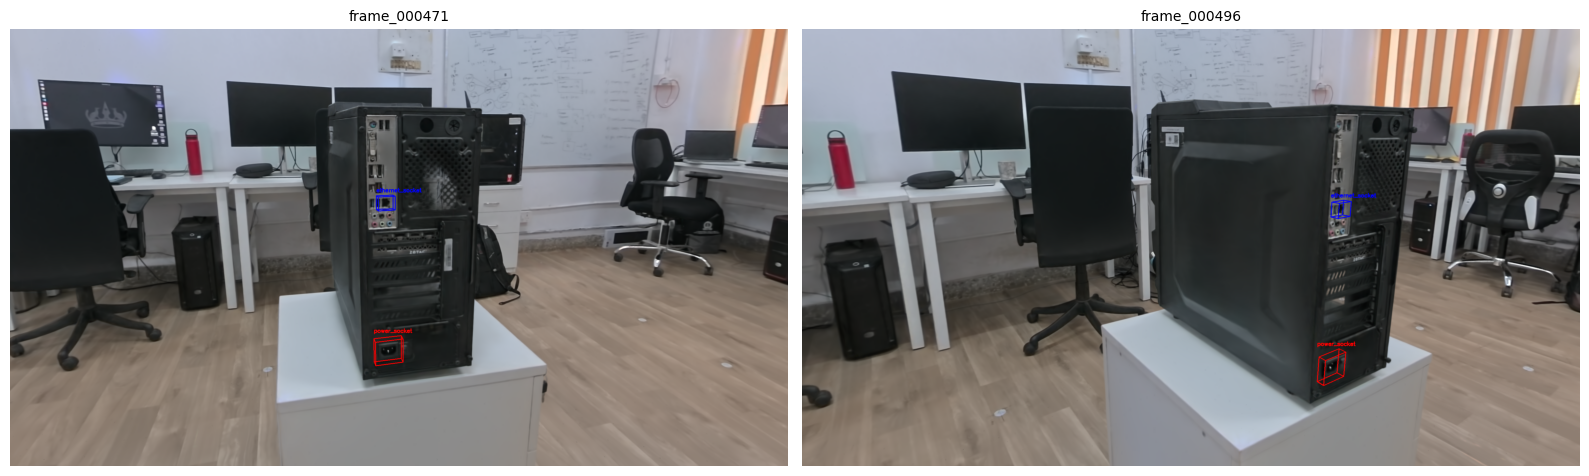

Visualisation complete.


In [ ]:
# ── OBB visualisation ────────────────────────────────────────────────────
viz_frames = [f for f in [471, 496] if f in images_bgr and f in all_poses]
fig, axes  = plt.subplots(1, len(viz_frames), figsize=(8*len(viz_frames), 7))
if len(viz_frames) == 1:
    axes = [axes]

for col, idx in enumerate(viz_frames):
    vis = images_bgr[idx].copy()
    for r in results:
        c2d     = project_obb(r['obb'], K, all_poses[idx])
        col_bgr = OBB_COLORS.get(r['entity'], (0, 255, 255))
        vis     = draw_obb(vis, c2d, r['entity'], col_bgr)
    cv2.imwrite(f"{OUTPUT_DIR}/detections/obb_{idx:06d}.png", vis)
    axes[col].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[col].set_title(f'frame_{idx:06d}', fontsize=10)
    axes[col].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/obb_projections.png', dpi=100)
plt.show()
print('Visualisation complete.')

## Final Answers

In [ ]:
with open(answers_path) as f:
    final = json.load(f)

print('=== FINAL ANSWERS ===')
print(json.dumps(final, indent=2))

=== FINAL ANSWERS ===
[
  {
    "entity": "power_socket",
    "obb": {
      "center": [
        0.28997311068809556,
        0.22501215955332285,
        0.5257812001757787
      ],
      "extent": [
        0.019708448442155496,
        0.021627409558727086,
        0.006
      ],
      "rotation": [
        [
          0.0,
          0.9988416978285708,
          -0.048117176527080044
        ],
        [
          -0.0,
          0.048117176527080044,
          0.9988416978285708
        ],
        [
          1.0,
          0.0,
          0.0
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.28860090308076947,
        0.22923242163347454,
        0.7554722528768493
      ],
      "extent": [
        0.01000707513406774,
        0.012336243725525171,
        0.006
      ],
      "rotation": [
        [
          0.0,
          0.9965260846195809,
          -0.0832812264004791
        ],
        [
          -0.0,
          0.0

In [ ]:
# Download answers.json
from google.colab import files
files.download(answers_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>